# Grid cells in the medial entorhinal cortex (DANDI:000582)

This notebook demonstrates grid cells in the rat medial entorhinal cortex (MEC)
using data streamed from the DANDI Archive. A grid cell fires whenever the animal
passes through any vertex of a hexagonal lattice that tiles the whole environment,
so its firing-rate map has multiple regularly spaced fields and its spatial
autocorrelogram has six peaks arranged at 60 degree intervals around the centre.

**Dataset.** [DANDI:000582](https://dandiarchive.org/dandiset/000582),
"Conjunctive Representation of Position, Direction, and Velocity in Entorhinal
Cortex" (Sargolini et al., *Science* 2006, Moser lab). It contains 118 NWB files
from 15 Long-Evans rats foraging for food in open arenas, with tetrode-sorted MEC
units and two head-mounted tracking LEDs sampled at 50 Hz. Each file records the
MEC layer the tetrode was in, which lets us ask where grid cells sit relative to
head-direction cells.

**What the notebook does.**

1. Streams every NWB file from S3 (remfile + a local disk cache; no full downloads)
   and surveys arena geometry, session length and unit counts.
2. Builds Pynapple objects (`TsGroup`, `TsdFrame`, `IntervalSet`) for spikes,
   position, head direction and running speed, and checks each stream visually.
3. Computes occupancy-normalised rate maps, spatial autocorrelograms, gridness
   scores, grid spacing and orientation, spatial information, split-half stability
   and head-direction tuning for every unit.
4. Calibrates significance with a circular-shift shuffle (100 shifts per unit) and
   classifies grid cells and head-direction cells against the 95th percentile of
   the pooled shuffled distributions.
5. Summarises the grid-cell population: prevalence, spacing, orientation alignment
   of co-recorded cells, and the laminar distribution of grid, head-direction and
   conjunctive cells.

Running time from scratch is roughly 10 minutes (dominated by the shuffle), after
which intermediate results are cached in CSV files next to the notebook.

## 1. Setup

In [1]:
import functools
import json
import multiprocessing as mp
import os
import urllib.request
import zlib

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
import remfile
from pynwb import NWBHDF5IO
from scipy import ndimage, signal
from tqdm.auto import tqdm

plt.rcParams.update({"font.size": 9, "axes.titlesize": 9, "figure.dpi": 130})

DANDISET = "000582"
API = "https://api.dandiarchive.org/api/dandisets"
CACHE_DIR = os.environ.get("REMFILE_CACHE", "/tmp/remfile_cache_000582")

# Analysis parameters, fixed once and used everywhere below.
BIN_CM = 3.0          # rate-map bin size
SMOOTH_BINS = 2.0     # Gaussian smoothing sigma, in bins (6 cm)
SPEED_MIN = 2.5       # cm/s: exclude immobility from spatial analyses
SPEED_MAX = 100.0     # cm/s: reject tracking jumps
HD_BINS = 60          # head-direction bins (6 deg)
N_SHUFFLE = 100       # circular time shifts per unit
MIN_SPIKES = 100      # minimum spikes during running for a unit to be analysed
RNG_SEED = 20260731

## 2. Streaming access to the dandiset

Assets are listed through the DANDI REST API and opened lazily with `remfile`,
which fetches only the byte ranges that h5py actually reads and keeps them in a
local disk cache. A whole session (position + spikes) is a few megabytes.

In [2]:
def list_assets():
    """Return [{'path', 'id', 'size'}] for every NWB file in the dandiset."""
    if os.path.exists("assets.json"):
        return json.load(open("assets.json"))
    url = f"{API}/{DANDISET}/versions/draft/assets/?page_size=200"
    out = []
    while url:
        d = json.load(urllib.request.urlopen(url))
        out += d["results"]
        url = d["next"]
    out = sorted(({"path": a["path"], "id": a["asset_id"], "size": a["size"]} for a in out),
                 key=lambda a: a["path"])
    json.dump(out, open("assets.json", "w"), indent=0)
    return out


def open_nwb(asset):
    """Stream one NWB file (an asset dict, or its path)."""
    if isinstance(asset, str):
        asset = [a for a in list_assets() if a["path"] == asset][0]
    url = f"{API}/{DANDISET}/versions/draft/assets/{asset['id']}/download/"
    fh = h5py.File(remfile.File(url, disk_cache=remfile.DiskCache(CACHE_DIR)), "r")
    return NWBHDF5IO(file=fh, load_namespaces=True).read()


assets = list_assets()
print("%d NWB files, %.0f MB total" % (len(assets), sum(a["size"] for a in assets) / 1e6))
nwb = open_nwb(assets[0])
print(nwb.session_description)
print("subject", nwb.subject.subject_id, "| lab", nwb.lab, "| units", len(nwb.units))
print("behavior:", list(nwb.processing["behavior"]["Position"].spatial_series))

118 NWB files, 1863 MB total


This session includes spike and position times for recorded cells from a Long Evans rat that was running in a 1 x 1 meter enclosure. The cells were recorded in the dorsocaudal 25% portion of the medial entorhinal cortex (MEC).Position is given for two LEDs to enable calculation of head direction.
subject 10073 | lab Moser | units 8
behavior: ['SpatialSeriesLED1']


## 3. Loading a session into Pynapple

Position is the midpoint of the two tracking LEDs and head direction is the angle
of the LED1 to LED2 vector. Short tracking dropouts are interpolated; gaps longer
than 0.5 s are left as NaN and dropped. Speed comes from a median-filtered
trajectory, and all spatial analyses are restricted to an `IntervalSet` of epochs
where the rat is moving between 2.5 and 100 cm/s.

In [3]:
def _runs(idx):
    if len(idx) == 0:
        return []
    breaks = np.flatnonzero(np.diff(idx) > 1)
    starts = np.r_[idx[0], idx[breaks + 1]]
    stops = np.r_[idx[breaks], idx[-1]]
    return list(zip(starts, stops))


def _interp_nans(x, t, max_gap_s=0.5):
    """Linearly interpolate short NaN gaps; leave long gaps as NaN."""
    x = x.copy()
    bad = np.isnan(x)
    if not bad.any():
        return x
    good = ~bad
    x[bad] = np.interp(t[bad], t[good], x[good])
    for start, stop in _runs(np.flatnonzero(bad)):
        if t[stop] - t[start] > max_gap_s:
            x[start:stop + 1] = np.nan
    return x


def load_session(asset):
    """Load one session into Pynapple objects."""
    nwb = open_nwb(asset)
    pos = nwb.processing["behavior"]["Position"]
    s1 = pos["SpatialSeriesLED1"]
    t = np.asarray(s1.timestamps[:], dtype=float)
    p1 = np.asarray(s1.data[:], dtype=float)
    p1 = np.column_stack([_interp_nans(p1[:, i], t) for i in range(2)])

    # a few sessions were tracked with a single LED: no head direction there
    has_led2 = "SpatialSeriesLED2" in pos.spatial_series
    if has_led2:
        p2 = np.asarray(pos["SpatialSeriesLED2"].data[:], dtype=float)
        p2 = np.column_stack([_interp_nans(p2[:, i], t) for i in range(2)])
        mid = 0.5 * (p1 + p2)
        hd = np.arctan2(p2[:, 1] - p1[:, 1], p2[:, 0] - p1[:, 0])
    else:
        mid, hd = p1, np.full(len(t), np.nan)

    ok = np.isfinite(mid).all(axis=1)
    t_ok, mid_ok, hd_ok = t[ok], mid[ok], hd[ok]

    xs = ndimage.median_filter(mid_ok[:, 0], size=5)
    ys = ndimage.median_filter(mid_ok[:, 1], size=5)
    dt = np.gradient(t_ok)
    speed = np.hypot(np.gradient(xs) / dt, np.gradient(ys) / dt)
    speed = ndimage.uniform_filter1d(speed, size=13)

    position = nap.TsdFrame(t=t_ok, d=mid_ok, columns=["x", "y"])
    hd_tsd = nap.Tsd(t=t_ok, d=np.mod(hd_ok, 2 * np.pi))
    speed_tsd = nap.Tsd(t=t_ok, d=speed)
    run_ep = speed_tsd.threshold(SPEED_MIN, "above").threshold(SPEED_MAX, "below").time_support

    udf = nwb.units.to_dataframe()
    spikes = {int(i): nap.Ts(t=np.sort(np.asarray(r["spike_times"], dtype=float)))
              for i, r in udf.iterrows()}
    units = nap.TsGroup(spikes, time_support=position.time_support,
                        unit_name=list(udf["unit_name"]), histology=list(udf["histology"]),
                        hemisphere=list(udf["hemisphere"]))
    return {
        "units": units, "position": position, "hd": hd_tsd, "speed": speed_tsd,
        "run_ep": run_ep,
        "meta": {"session_id": nwb.session_id, "subject_id": nwb.subject.subject_id,
                 "path": asset["path"] if isinstance(asset, dict) else asset,
                 "duration_s": float(t_ok[-1] - t_ok[0]), "has_hd": bool(has_led2)},
    }


PROTO = "sub-11265/sub-11265_ses-06020601_behavior+ecephys.nwb"
s = load_session(PROTO)
print(s["meta"])
print(s["units"])
print("moving for %.0f of %.0f s in %d epochs"
      % (s["run_ep"].tot_length(), s["meta"]["duration_s"], len(s["run_ep"])))

{'session_id': '06020601', 'subject_id': '11265', 'path': 'sub-11265/sub-11265_ses-06020601_behavior+ecephys.nwb', 'duration_s': 599.98, 'has_hd': True}
  Index     rate  unit_name    histology    hemisphere
-------  -------  -----------  -----------  ------------
      0  0.91003  t1c1         MEC LIII     Right
      1  2.05507  t1c2         MEC LIII     Right
      2  0.60669  t2c1         MEC LIII     Right
      3  1.66339  t2c2         MEC LIII     Right
      4  1.77506  t2c3         MEC LIII     Right
      5  5.33351  t2c4         MEC LIII     Right
      6  0.74502  t3c1         MEC LIII     Right
      7  2.1334   t3c3         MEC LIII     Right
      8  1.52338  t3c5         MEC LIII     Right
      9  1.8634   t3c6         MEC LIII     Right
     10  0.85836  t4c1         MEC LIII     Right
     11  1.72839  t4c2         MEC LIII     Right
     12  1.76006  t4c4         MEC LIII     Right
     13  1.1217   t4c5         MEC LIII     Right
     14  1.46505  t5c1         MEC 

/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/time_series.py:3052: UserWarning: Some epochs have no duration
  time_support = IntervalSet(start=ns, end=ne)
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


## 4. Survey of all sessions

Most sessions use a 1 x 1 m square box; twenty sessions use a much larger circular
arena. To keep the geometry comparable we analyse the square-box sessions, and to
avoid counting the same cell twice we keep one session (the one with most units)
per rat per recording day.

In [4]:
def survey_sessions():
    if os.path.exists("session_survey.csv"):
        return pd.read_csv("session_survey.csv")
    rows = []
    for a in tqdm(list_assets(), desc="survey"):
        nwb = open_nwb(a)
        ss = nwb.processing["behavior"]["Position"]["SpatialSeriesLED1"]
        t = np.asarray(ss.timestamps[:])
        d = np.asarray(ss.data[:], dtype=float)
        d = d[np.isfinite(d).all(axis=1)]
        q = np.percentile(d, [0.5, 99.5], axis=0)
        H, _, _ = np.histogram2d(d[:, 0], d[:, 1], bins=20)
        rows.append(dict(path=a["path"], subject=nwb.subject.subject_id, session=nwb.session_id,
                         dur=float(t[-1] - t[0]), n_units=len(nwb.units),
                         ext_x=q[1, 0] - q[0, 0], ext_y=q[1, 1] - q[0, 1],
                         fill=(H > 0).mean(),
                         histology=str(nwb.units["histology"][0]) if len(nwb.units) else ""))
    df = pd.DataFrame(rows)
    df["shape"] = np.where(df.fill > 0.9, "square", "circle")
    df.to_csv("session_survey.csv", index=False)
    return df


survey = survey_sessions()
print(survey.groupby("shape").agg(sessions=("path", "size"), units=("n_units", "sum"),
                                  median_extent_cm=("ext_x", "median")).round(1))
print(survey.histology.value_counts())

sel = survey[(survey["shape"] == "square") & (survey.ext_x < 110) & (survey.ext_y < 110)].copy()
sel["date"] = sel.session.astype(str).str.zfill(8).str[:6]
sel = (sel.sort_values(["n_units", "dur"], ascending=False)
          .groupby(["subject", "date"], as_index=False).first().sort_values("path"))
print("\nselected %d sessions from %d rats, %d units"
      % (len(sel), sel.subject.nunique(), sel.n_units.sum()))

        sessions  units  median_extent_cm
shape                                    
circle        22    140             185.9
square        96    480              96.1
histology
MEC LIII    51
MEC LVI     31
MEC LV      25
MEC LII     10
Name: count, dtype: int64

selected 84 sessions from 15 rats, 430 units


## 5. Checking the raw data streams

Before any analysis, look at the trajectory, the tracked coordinates, running
speed, the spike raster and the occupancy map for the prototype session.

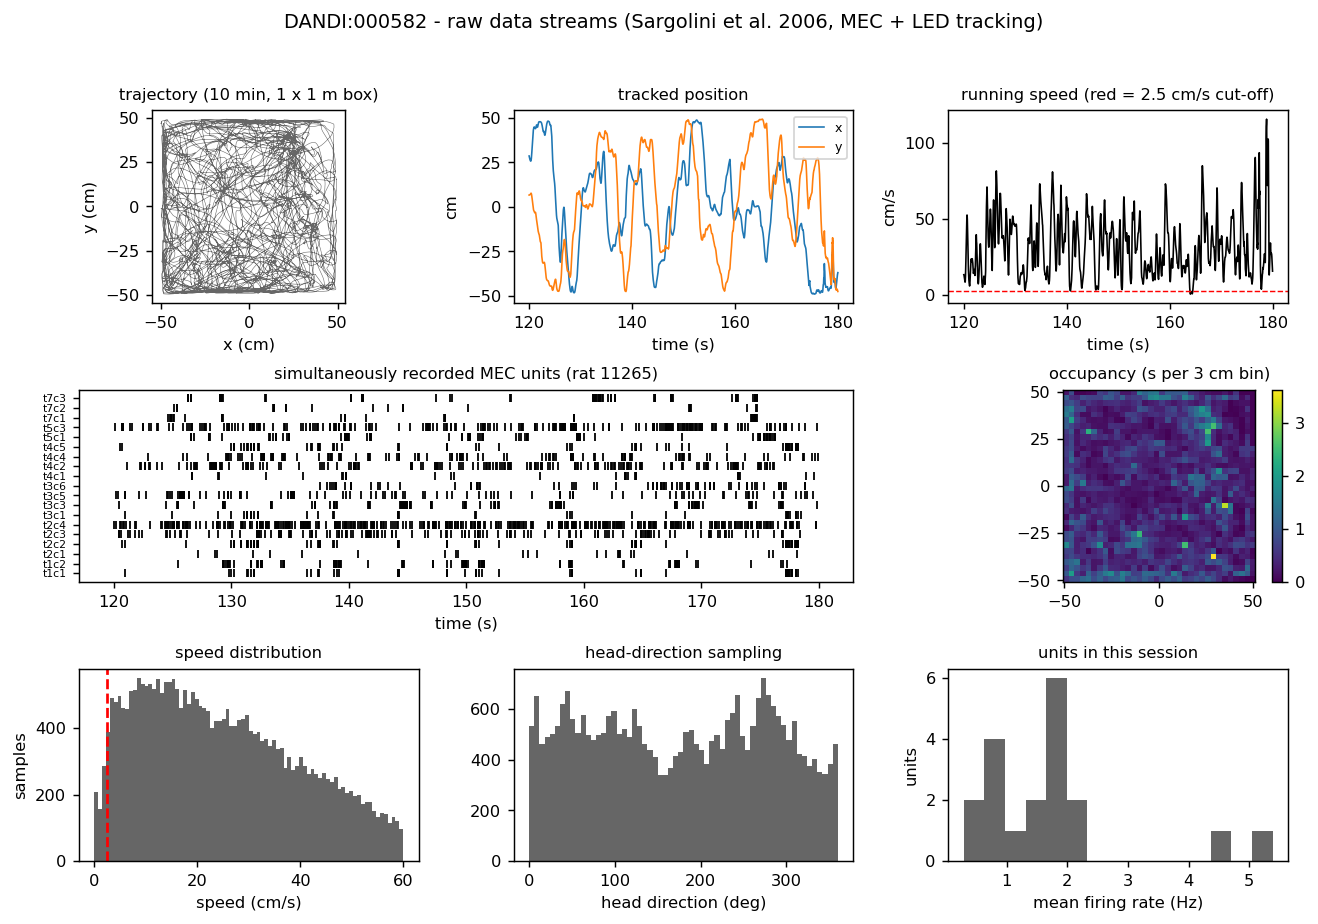

In [5]:
def map_edges(position, bin_cm=BIN_CM, pad=1.0):
    """Common square bin edges covering the visited arena."""
    x, y = position["x"].values, position["y"].values
    lo = min(np.percentile(x, 0.1), np.percentile(y, 0.1)) - pad
    hi = max(np.percentile(x, 99.9), np.percentile(y, 99.9)) + pad
    return lo + np.arange(int(np.ceil((hi - lo) / bin_cm)) + 1) * bin_cm


def _nan_gaussian(a, sigma):
    """Gaussian smoothing that ignores NaNs (normalised by the smoothed mask)."""
    if sigma <= 0:
        return a
    v = np.nan_to_num(a, nan=0.0)
    w = np.isfinite(a).astype(float)
    vs = ndimage.gaussian_filter(v, sigma, mode="constant")
    ws = ndimage.gaussian_filter(w, sigma, mode="constant")
    with np.errstate(invalid="ignore", divide="ignore"):
        out = vs / ws
    out[ws < 1e-6] = np.nan
    return out


def rate_maps(units, position, ep, edges, sigma=SMOOTH_BINS, min_occ=0.04):
    """Occupancy-normalised, Gaussian-smoothed 2-D rate maps.

    Spike counts and occupancy are smoothed separately and then divided; bins
    visited for less than `min_occ` seconds are treated as unvisited (NaN).
    """
    tc = nap.compute_tuning_curves(units, position, bins=[edges, edges], epochs=ep,
                                   return_counts=True)
    counts = np.asarray(tc.values)                         # (n_units, nx, ny)
    occ = np.asarray(tc.attrs["occupancy"], float) / float(tc.attrs["fs"])  # seconds
    unvisited = occ < min_occ
    occ_s = _nan_gaussian(np.where(unvisited, np.nan, occ), sigma)
    out = np.empty((counts.shape[0], occ.shape[1], occ.shape[0]))
    for i in range(counts.shape[0]):
        m = _nan_gaussian(np.where(unvisited, np.nan, counts[i]), sigma) / occ_s
        m[unvisited] = np.nan
        out[i] = m.T                                       # (ny, nx), for imshow
    return out, occ.T, 0.5 * (edges[:-1] + edges[1:])


pos, units, ep = s["position"], s["units"], s["run_ep"]
edges = map_edges(pos)
maps, occ, centers = rate_maps(units, pos, ep, edges)
ext = [edges[0], edges[-1], edges[0], edges[-1]]

fig = plt.figure(figsize=(12, 7.5))
gsp = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.28)
ax = fig.add_subplot(gsp[0, 0])
ax.plot(pos["x"].values, pos["y"].values, lw=0.3, color="0.4")
ax.set_aspect("equal"); ax.set_title("trajectory (10 min, 1 x 1 m box)")
ax.set_xlabel("x (cm)"); ax.set_ylabel("y (cm)")
ax = fig.add_subplot(gsp[0, 1])
seg = pos.get(120, 180)
ax.plot(seg.index, seg["x"].values, lw=0.9, label="x")
ax.plot(seg.index, seg["y"].values, lw=0.9, label="y")
ax.legend(fontsize=7, loc="upper right"); ax.set_xlabel("time (s)"); ax.set_ylabel("cm")
ax.set_title("tracked position")
ax = fig.add_subplot(gsp[0, 2])
seg = s["speed"].get(120, 180)
ax.plot(seg.index, seg.values, lw=0.9, color="k")
ax.axhline(SPEED_MIN, color="r", ls="--", lw=0.8)
ax.set_xlabel("time (s)"); ax.set_ylabel("cm/s")
ax.set_title("running speed (red = %.1f cm/s cut-off)" % SPEED_MIN)
ax = fig.add_subplot(gsp[1, :2])
names = list(units.get_info("unit_name"))
for i in range(len(units)):
    tt = units[i].get(120, 180).times()
    ax.plot(tt, np.full_like(tt, i), "|", ms=4, color="k", lw=0.5)
ax.set_yticks(range(len(units))); ax.set_yticklabels(names, fontsize=6)
ax.set_xlabel("time (s)"); ax.set_title("simultaneously recorded MEC units (rat %s)"
                                        % s["meta"]["subject_id"])
ax = fig.add_subplot(gsp[1, 2])
im = ax.imshow(occ, origin="lower", cmap="viridis", extent=ext)
ax.set_aspect("equal"); ax.set_title("occupancy (s per 3 cm bin)")
plt.colorbar(im, ax=ax, fraction=0.046)
ax = fig.add_subplot(gsp[2, 0])
ax.hist(s["speed"].values, bins=80, range=(0, 60), color="0.4")
ax.axvline(SPEED_MIN, color="r", ls="--"); ax.set_xlabel("speed (cm/s)"); ax.set_ylabel("samples")
ax.set_title("speed distribution")
ax = fig.add_subplot(gsp[2, 1])
ax.hist(np.degrees(s["hd"].values), bins=60, color="0.4")
ax.set_xlabel("head direction (deg)"); ax.set_title("head-direction sampling")
ax = fig.add_subplot(gsp[2, 2])
ax.hist([len(units[i].restrict(ep)) / ep.tot_length() for i in range(len(units))],
        bins=15, color="0.4")
ax.set_xlabel("mean firing rate (Hz)"); ax.set_ylabel("units")
ax.set_title("units in this session")
fig.suptitle("DANDI:000582 - raw data streams (Sargolini et al. 2006, MEC + LED tracking)", y=0.98)
fig.savefig("fig01_raw_data_streams.png", bbox_inches="tight")

## 6. Rate maps, autocorrelograms and gridness

The spatial autocorrelogram is the Pearson correlation between the rate map and a
copy of itself shifted by every possible (x, y) lag, computed over the bins where
both copies are defined (Sargolini et al. 2006). For a hexagonal firing pattern it
has six peaks around the centre at 60 degree intervals.

The gridness score takes the ring of the autocorrelogram that excludes the central
peak, rotates it, and compares the rotated ring to the original:

`gridness = min(r60, r120) - max(r30, r90, r150)`

maximised over a range of outer radii. A perfect hexagonal lattice correlates well
with itself at 60 and 120 degrees and poorly at 30, 90 and 150 degrees, so gridness
is large and positive; a single field or a band pattern gives values near or below
zero.

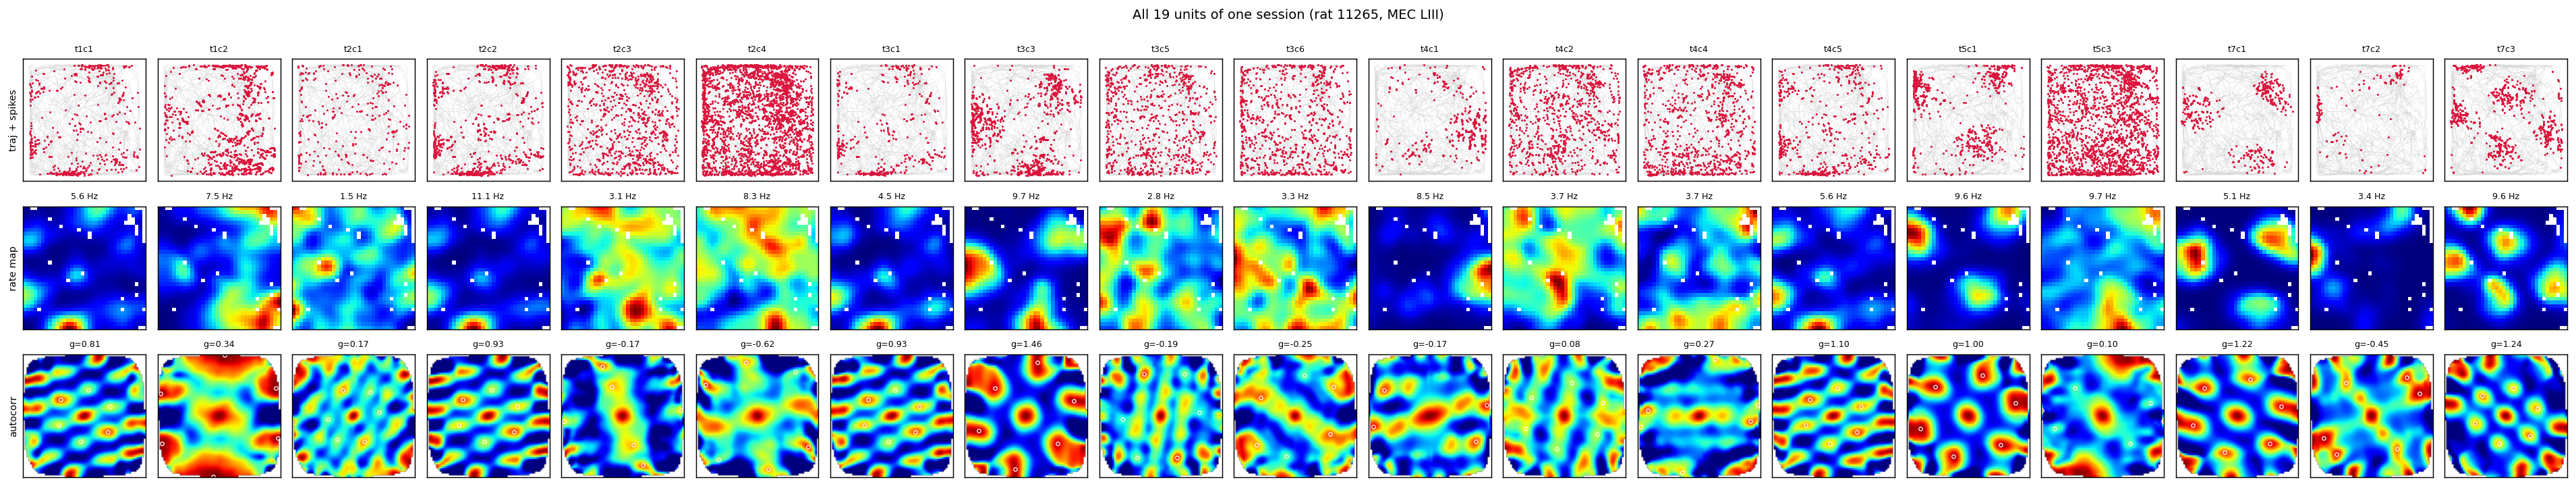

In [6]:
def spatial_autocorr(rmap, min_overlap=20):
    """Unbiased Pearson spatial autocorrelogram of a rate map."""
    f = np.nan_to_num(rmap, nan=0.0)
    m = np.isfinite(rmap).astype(float)
    c = lambda a, b: signal.fftconvolve(a, b[::-1, ::-1], mode="full")
    n, sfg, sf, sg = c(m, m), c(f, f), c(f, m), c(m, f)
    sff, sgg = c(f * f, m), c(m, f * f)
    with np.errstate(invalid="ignore", divide="ignore"):
        num = n * sfg - sf * sg
        den = np.sqrt(np.clip(n * sff - sf ** 2, 0, None) * np.clip(n * sgg - sg ** 2, 0, None))
        r = num / den
    r[n < min_overlap] = np.nan
    return np.clip(r, -1, 1)


def _radial_profile(ac):
    ny, nx = ac.shape
    yy, xx = np.mgrid[:ny, :nx]
    rr = np.hypot(yy - (ny - 1) / 2, xx - (nx - 1) / 2).astype(int)
    prof = np.full(rr.max() + 1, np.nan)
    for k in range(rr.max() + 1):
        sel = (rr == k) & np.isfinite(ac)
        if sel.sum() >= 3:
            prof[k] = ac[sel].mean()
    return prof


def central_peak_radius(ac):
    """Radius (bins) of the first minimum of the radial autocorrelation profile."""
    prof = np.where(np.isfinite(_radial_profile(ac)), _radial_profile(ac), 0.0)
    for k in range(1, len(prof) - 1):
        if prof[k] <= prof[k + 1] and prof[k] < prof[0]:
            return max(k, 2)
    return max(len(prof) // 6, 2)


def _rotate_about_center(a, deg):
    rf = ndimage.rotate(np.nan_to_num(a, nan=0.0), deg, reshape=False, order=1, cval=0.0)
    rm = ndimage.rotate(np.isfinite(a).astype(float), deg, reshape=False, order=1, cval=0.0)
    return np.where(rm > 0.5, rf, np.nan)


def gridness(ac, r_in=None, n_radii=8):
    """Gridness score, maximised over expanding annuli."""
    ny, nx = ac.shape
    cy, cx = (ny - 1) / 2, (nx - 1) / 2
    rr = np.hypot(np.mgrid[:ny, :nx][0] - cy, np.mgrid[:ny, :nx][1] - cx)
    r_max = min(cy, cx)
    r_in = min(central_peak_radius(ac) if r_in is None else r_in, max(r_max - 6, 2))
    if r_max <= r_in + 3:
        return np.nan, np.nan
    rot = {a: _rotate_about_center(ac, a) for a in (30, 60, 90, 120, 150)}
    best, best_r = -np.inf, np.nan
    for r_out in np.linspace(r_in + 3, r_max, n_radii):
        ring = (rr >= r_in) & (rr <= r_out)
        cs = {}
        for a, ra in rot.items():
            sel = ring & np.isfinite(ac) & np.isfinite(ra)
            if sel.sum() < 20:
                cs = None
                break
            cs[a] = np.corrcoef(ac[sel], ra[sel])[0, 1]
        if cs is None:
            continue
        g = min(cs[60], cs[120]) - max(cs[30], cs[90], cs[150])
        if g > best:
            best, best_r = g, r_out
    return (best if np.isfinite(best) else np.nan), best_r


def autocorr_peaks(ac, bin_cm=BIN_CM, n_peaks=6):
    """Six autocorrelogram peaks closest to the centre -> spacing, orientation."""
    ny, nx = ac.shape
    cy, cx = (ny - 1) / 2, (nx - 1) / 2
    a = np.nan_to_num(ac, nan=-1.0)
    ys, xs = np.nonzero((ndimage.maximum_filter(a, size=5) == a) & (a > 0.1))
    d = np.hypot(ys - cy, xs - cx)
    keep = d > max(central_peak_radius(ac) * 0.8, 2)
    ys, xs, d = ys[keep], xs[keep], d[keep]
    if len(d) == 0:
        return np.nan, np.nan, np.nan, np.zeros((0, 2))
    o = np.argsort(d)[:n_peaks]
    ys, xs, d = ys[o], xs[o], d[o]
    ang = np.degrees(np.arctan2(ys - cy, xs - cx))
    return (float(np.median(d) * bin_cm), float(np.min(np.mod(ang, 60.0))),
            float(d.max() / d.min()) if len(d) >= 3 else np.nan,
            np.column_stack([xs, ys]))


def rotational_correlation(ac, angles=np.arange(0, 181, 3)):
    """Correlation of the autocorrelogram annulus with itself, vs rotation angle."""
    ny, nx = ac.shape
    cy, cx = (ny - 1) / 2, (nx - 1) / 2
    rr = np.hypot(np.mgrid[:ny, :nx][0] - cy, np.mgrid[:ny, :nx][1] - cx)
    ring = (rr >= min(central_peak_radius(ac), max(min(cy, cx) - 6, 2))) & (rr <= min(cy, cx))
    out = []
    for a in angles:
        ra = _rotate_about_center(ac, a)
        sel = ring & np.isfinite(ac) & np.isfinite(ra)
        out.append(np.corrcoef(ac[sel], ra[sel])[0, 1] if sel.sum() > 20 else np.nan)
    return np.asarray(angles, float), np.asarray(out)


def spatial_information(rmap, occ):
    """Skaggs spatial information, bits per spike."""
    v = np.isfinite(rmap) & (occ > 0)
    r, o = rmap[v], occ[v]
    p = o / o.sum()
    mean_r = np.sum(p * r)
    if mean_r <= 0:
        return np.nan
    nz = r > 0
    return float(np.sum(p[nz] * (r[nz] / mean_r) * np.log2(r[nz] / mean_r)))


def map_correlation(a, b):
    v = np.isfinite(a) & np.isfinite(b)
    return float(np.corrcoef(a[v], b[v])[0, 1]) if v.sum() >= 20 else np.nan


def hd_tuning(units, hd, ep, nbins=HD_BINS):
    """Head-direction tuning curves and mean vector length per unit."""
    tc = nap.compute_tuning_curves(units, hd, bins=nbins, range=[(0, 2 * np.pi)], epochs=ep)
    curves = np.asarray(tc.values).T                    # (nbins, n_units)
    centers = np.asarray(tc.coords[tc.dims[1]].values)  # dims are ('unit', feature)
    mvl = []
    for i in range(curves.shape[1]):
        c = np.nan_to_num(curves[:, i])
        mvl.append(float(np.abs(np.sum(c * np.exp(1j * centers))) / c.sum()) if c.sum() > 0
                   else np.nan)
    return curves, centers, np.array(mvl)


def shift_spikes(ts, shift, t0, t1):
    """Circularly shift spike times inside [t0, t1] (the shuffle control)."""
    return nap.Ts(t=np.sort(t0 + np.mod(ts.times() - t0 + shift, t1 - t0)))


# every unit of the prototype session
fig, axes = plt.subplots(3, len(units), figsize=(1.55 * len(units), 5.6))
for i in range(len(units)):
    sp = units[i].restrict(ep).value_from(pos)
    axes[0, i].plot(pos["x"].values, pos["y"].values, lw=0.2, color="0.85")
    axes[0, i].plot(sp["x"].values, sp["y"].values, ".", ms=1.4, color="crimson")
    axes[0, i].set_title(names[i], fontsize=7)
    axes[1, i].imshow(maps[i], origin="lower", extent=ext, cmap="jet")
    axes[1, i].set_title("%.1f Hz" % np.nanmax(maps[i]), fontsize=7)
    ac = spatial_autocorr(maps[i])
    g, _ = gridness(ac)
    spacing, ori, ell, pk = autocorr_peaks(ac)
    axes[2, i].imshow(ac, origin="lower", cmap="jet", vmin=-0.5, vmax=1)
    axes[2, i].plot(pk[:, 0], pk[:, 1], "o", mfc="none", mec="w", ms=3, mew=0.7)
    axes[2, i].set_title("g=%.2f" % g, fontsize=7)
    for r in range(3):
        axes[r, i].set_aspect("equal"); axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
for r, lab in enumerate(["traj + spikes", "rate map", "autocorr"]):
    axes[r, 0].set_ylabel(lab, fontsize=8)
fig.suptitle("All %d units of one session (rat %s, %s)"
             % (len(units), s["meta"]["subject_id"], s["units"].get_info("histology")[0]), y=1.0)
fig.tight_layout()
fig.savefig("fig_check_session_all_units.png", bbox_inches="tight")

Several units in this single session already show the hexagonal signature. The
next step quantifies it for every unit in the dataset.

## 7. Population analysis with a shuffle control

For each unit we compute gridness, spacing, orientation, spatial information,
split-half stability (correlation between rate maps built from the first and
second half of the session) and head-direction tuning. Significance comes from a
circular-shift shuffle: spike times are shifted by a random offset of at least
20 s and wrapped around the session, which destroys the spike-position
relationship while preserving each unit's firing statistics. The 95th percentile
of the pooled shuffled distribution is the classification threshold.

In [7]:
def analyze_session(path, n_shuffle=N_SHUFFLE):
    s = load_session(path)
    pos, units, ep, hd, meta = s["position"], s["units"], s["run_ep"], s["hd"], s["meta"]
    edges = map_edges(pos)
    maps, occ, _ = rate_maps(units, pos, ep, edges)

    t_mid = 0.5 * (pos.index[0] + pos.index[-1])
    maps1, _, _ = rate_maps(units, pos, ep.intersect(nap.IntervalSet(pos.index[0], t_mid)), edges)
    maps2, _, _ = rate_maps(units, pos, ep.intersect(nap.IntervalSet(t_mid, pos.index[-1])), edges)

    if meta["has_hd"]:
        curves, centers, mvl = hd_tuning(units, hd, ep)
    else:
        curves = np.full((HD_BINS, len(units)), np.nan)
        centers = np.linspace(0, 2 * np.pi, HD_BINS, endpoint=False)
        mvl = np.full(len(units), np.nan)

    names = list(units.get_info("unit_name"))
    hist = list(units.get_info("histology"))
    rows, shuf_g, shuf_m = [], [], []
    for i, u in enumerate(units.keys()):
        n_spk = len(units[u].restrict(ep))
        ac = spatial_autocorr(maps[i])
        g, _ = gridness(ac)
        spacing, ori, ell, _ = autocorr_peaks(ac)
        rows.append(dict(
            path=meta["path"], subject=meta["subject_id"], session=meta["session_id"],
            unit=names[i], layer=str(hist[i]), n_spikes=n_spk,
            mean_rate=n_spk / ep.tot_length(), peak_rate=float(np.nanmax(maps[i])),
            gridness=g, spacing_cm=spacing, orientation_deg=ori, ellipticity=ell,
            spatial_info=spatial_information(maps[i], occ),
            stability=map_correlation(maps1[i], maps2[i]), hd_mvl=mvl[i],
            hd_pref_deg=(float(np.degrees(centers[np.nanargmax(curves[:, i])]))
                         if np.isfinite(curves[:, i]).any() else np.nan)))

    rng = np.random.default_rng(zlib.crc32(path.encode()) ^ RNG_SEED)
    t0, t1 = float(pos.index[0]), float(pos.index[-1])
    keys = list(units.keys())
    for _ in range(n_shuffle):
        shifts = rng.uniform(20.0, (t1 - t0) - 20.0, size=len(keys))
        sh = nap.TsGroup({k: shift_spikes(units[k], shifts[j], t0, t1)
                          for j, k in enumerate(keys)}, time_support=pos.time_support)
        smaps, _, _ = rate_maps(sh, pos, ep, edges)
        smvl = hd_tuning(sh, hd, ep)[2] if meta["has_hd"] else np.full(len(keys), np.nan)
        for i in range(len(keys)):
            shuf_g.append((names[i], gridness(spatial_autocorr(smaps[i]))[0]))
            shuf_m.append((names[i], smvl[i]))
    return (pd.DataFrame(rows),
            pd.DataFrame(shuf_g, columns=["unit", "gridness"]).assign(path=meta["path"]),
            pd.DataFrame(shuf_m, columns=["unit", "hd_mvl"]).assign(path=meta["path"]))


def run_population(paths):
    """Analyse all sessions (in parallel where possible) and cache the results."""
    cached = ["unit_metrics.csv", "shuffle_gridness.csv", "shuffle_mvl.csv"]
    if all(os.path.exists(c) for c in cached):
        print("using cached results:", ", ".join(cached))
        return [pd.read_csv(c) for c in cached]
    if hasattr(os, "fork"):
        ctx = mp.get_context("fork")
        with ctx.Pool(min(6, len(paths))) as pool:
            out = list(tqdm(pool.imap_unordered(analyze_session, paths), total=len(paths)))
    else:
        out = [analyze_session(p) for p in tqdm(paths)]
    units_df = pd.concat([o[0] for o in out], ignore_index=True)
    units_df = units_df[units_df.n_spikes >= MIN_SPIKES].reset_index(drop=True)
    keep = set(map(tuple, units_df[["path", "unit"]].values))
    sg = pd.concat([o[1] for o in out], ignore_index=True)
    sm = pd.concat([o[2] for o in out], ignore_index=True)
    sg = sg[[tuple(x) in keep for x in sg[["path", "unit"]].values]]
    sm = sm[[tuple(x) in keep for x in sm[["path", "unit"]].values]]
    for d, f in zip((units_df, sg, sm), cached):
        d.to_csv(f, index=False)
    return units_df, sg, sm


units_df, shuf_g, shuf_m = run_population(list(sel.path))
G_THR = float(np.nanpercentile(shuf_g.gridness, 95))
M_THR = float(np.nanpercentile(shuf_m.hd_mvl, 95))
units_df["is_grid"] = units_df.gridness > G_THR
units_df["is_hd"] = units_df.hd_mvl > M_THR
print("%d units, %d sessions, %d rats" % (len(units_df), units_df.path.nunique(),
                                          units_df.subject.nunique()))
print("gridness threshold %.3f -> %d grid cells (%.1f%%)"
      % (G_THR, units_df.is_grid.sum(), 100 * units_df.is_grid.mean()))
print("HD mean-vector-length threshold %.3f" % M_THR)

using cached results: unit_metrics.csv, shuffle_gridness.csv, shuffle_mvl.csv
430 units, 84 sessions, 15 rats
gridness threshold 0.658 -> 121 grid cells (28.1%)
HD mean-vector-length threshold 0.203


## 8. Example grid cells

The eight highest-gridness cells, one per rat.

/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/time_series.py:3052: UserWarning: Some epochs have no duration
  time_support = IntervalSet(start=ns, end=ne)
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/time_series.py:3052: UserWarning: Some epochs have no duration
  time_support = IntervalSet(start=ns, end=ne)
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/time_series.py:3052: UserWarning: Some epochs have no duration
  time_support = IntervalSet(start=ns, end=ne)
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/time_series.py:3052: UserWarning: Some epochs have no duration
  time_support = IntervalSet(start=ns, end=ne)
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/time_series.py:3052: UserWarning: Some epochs have no duration
  time_support = IntervalSet(start=ns, end=ne)
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/time_series.py:3052: UserWarning: Some epochs have no duration
  time_support = IntervalSet(start=ns, end=ne)
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/time_series.py:3052: UserWarning: Some epochs have no duration
  time_support = IntervalSet(start=ns, end=ne)
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


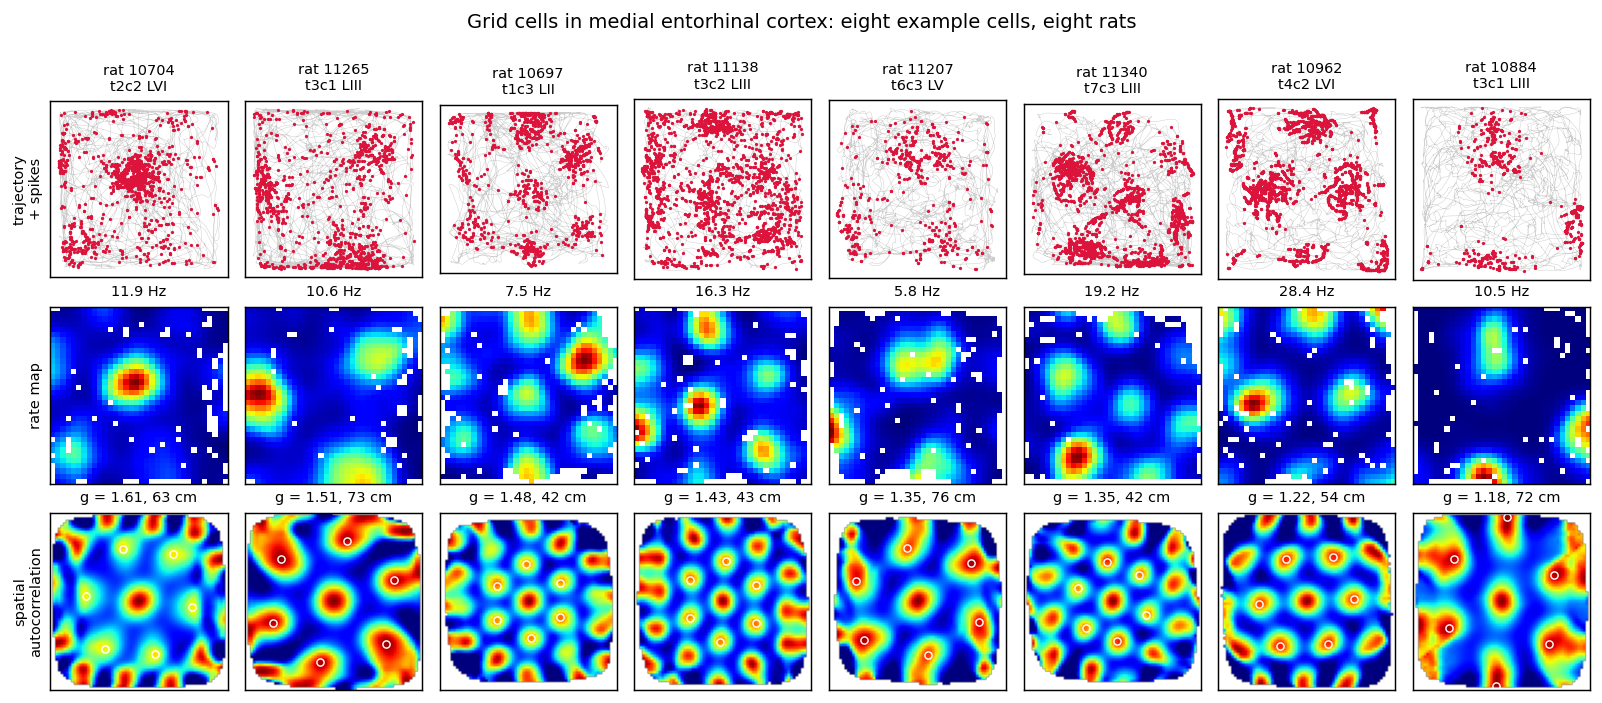

In [8]:
@functools.lru_cache(maxsize=8)
def cached_session(path):
    s = load_session(path)
    s["edges"] = map_edges(s["position"])
    s["maps"], s["occ"], _ = rate_maps(s["units"], s["position"], s["run_ep"], s["edges"])
    return s


def unit_index(s, name):
    return list(s["units"].get_info("unit_name")).index(name)


def draw_cell(axes, path, name, label=""):
    s_ = cached_session(path)
    i = unit_index(s_, name)
    e = s_["edges"]
    ex = [e[0], e[-1], e[0], e[-1]]
    sp = s_["units"][i].restrict(s_["run_ep"]).value_from(s_["position"])
    axes[0].plot(s_["position"]["x"].values, s_["position"]["y"].values, lw=0.25, color="0.8")
    axes[0].plot(sp["x"].values, sp["y"].values, ".", ms=1.6, color="crimson")
    axes[0].set_title(label, fontsize=8)
    axes[1].imshow(s_["maps"][i], origin="lower", extent=ex, cmap="jet")
    axes[1].set_title("%.1f Hz" % np.nanmax(s_["maps"][i]), fontsize=8)
    ac = spatial_autocorr(s_["maps"][i])
    g, _ = gridness(ac)
    spacing, ori, ell, pk = autocorr_peaks(ac)
    axes[2].imshow(ac, origin="lower", cmap="jet", vmin=-0.5, vmax=1.0)
    axes[2].plot(pk[:, 0], pk[:, 1], "o", mfc="none", mec="w", ms=4, mew=0.8)
    axes[2].set_title("g = %.2f, %.0f cm" % (g, spacing), fontsize=8)
    for a in axes:
        a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])


best = (units_df[units_df.is_grid].sort_values("gridness", ascending=False)
        .drop_duplicates("subject").head(8))
fig, axes = plt.subplots(3, len(best), figsize=(1.55 * len(best), 5.4))
for j, (_, r) in enumerate(best.iterrows()):
    draw_cell(axes[:, j], r.path, r.unit,
              label="rat %s\n%s %s" % (r.subject, r.unit, r.layer.replace("MEC ", "")))
for row, lab in enumerate(["trajectory\n+ spikes", "rate map", "spatial\nautocorrelation"]):
    axes[row, 0].set_ylabel(lab, fontsize=8)
fig.suptitle("Grid cells in medial entorhinal cortex: eight example cells, eight rats", y=1.0)
fig.tight_layout()
fig.savefig("fig02_example_grid_cells.png", bbox_inches="tight")

## 9. What the gridness score measures

The left column shows rate maps, the middle column their autocorrelograms, and the
right column the correlation of the autocorrelogram with a rotated copy of itself.
The grid cell peaks at 60 and 120 degrees and dips at 30, 90 and 150 degrees. The
comparison cell has a band-like map, so its rotational correlation peaks at 90
degrees and gridness is strongly negative.

/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/time_series.py:3052: UserWarning: Some epochs have no duration
  time_support = IntervalSet(start=ns, end=ne)
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


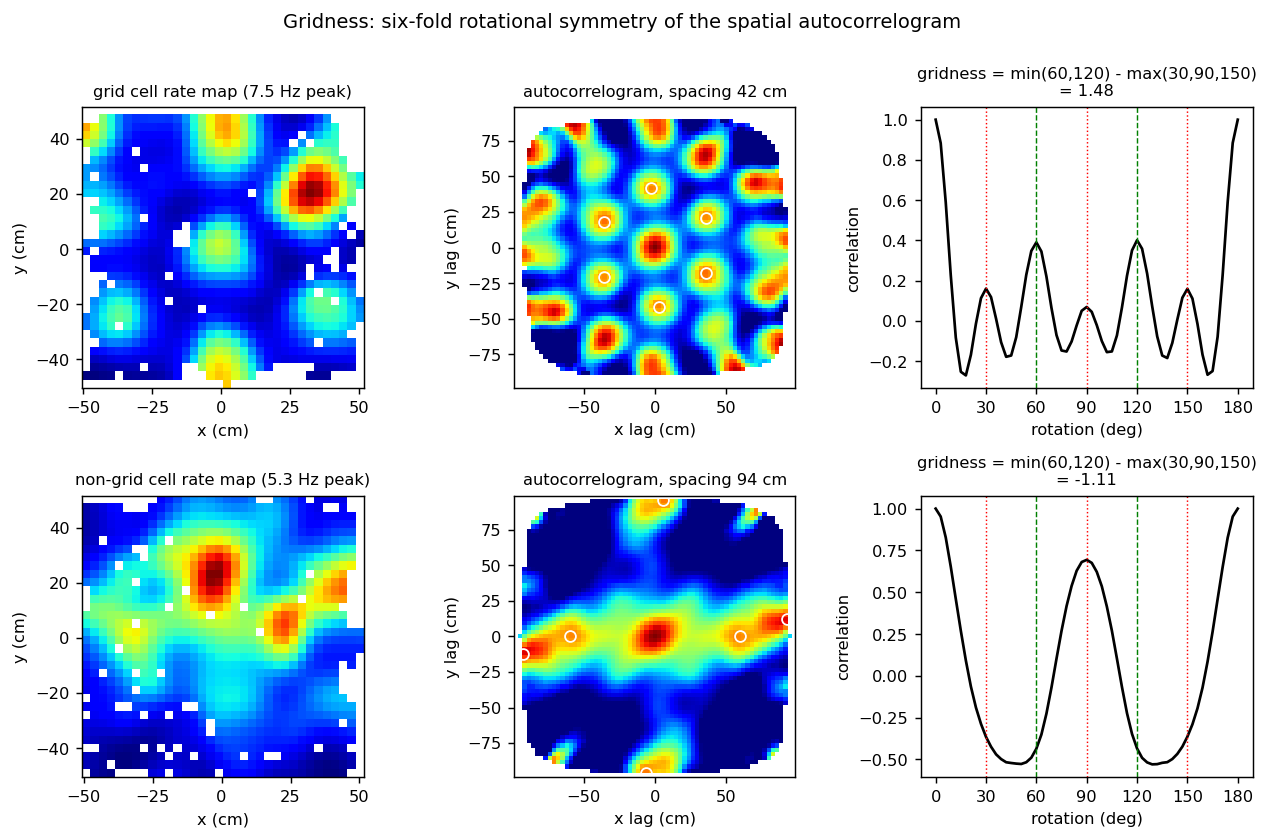

In [9]:
ex = (units_df[(units_df.gridness > 1.2) & (units_df.spacing_cm < 50)]
      .sort_values("gridness", ascending=False).iloc[0])
non = (units_df[(~units_df.is_grid) & (units_df.n_spikes > 800)].sort_values("gridness").iloc[0])
fig, axes = plt.subplots(2, 3, figsize=(10, 6.4))
for row, r in enumerate([ex, non]):
    s_ = cached_session(r.path)
    i = unit_index(s_, r.unit)
    e = s_["edges"]
    ac = spatial_autocorr(s_["maps"][i])
    axes[row, 0].imshow(s_["maps"][i], origin="lower", extent=[e[0], e[-1], e[0], e[-1]], cmap="jet")
    axes[row, 0].set_aspect("equal"); axes[row, 0].set_xlabel("x (cm)"); axes[row, 0].set_ylabel("y (cm)")
    axes[row, 0].set_title("%s rate map (%.1f Hz peak)"
                           % ("grid cell" if row == 0 else "non-grid cell", np.nanmax(s_["maps"][i])))
    n = ac.shape[0]
    half = (n - 1) / 2 * BIN_CM
    axes[row, 1].imshow(ac, origin="lower", cmap="jet", vmin=-0.5, vmax=1,
                        extent=[-half, half, -half, half])
    spacing, ori, ell, pk = autocorr_peaks(ac)
    axes[row, 1].plot((pk[:, 0] - (n - 1) / 2) * BIN_CM, (pk[:, 1] - (n - 1) / 2) * BIN_CM,
                      "o", mfc="none", mec="w", ms=6)
    axes[row, 1].set_aspect("equal"); axes[row, 1].set_xlabel("x lag (cm)")
    axes[row, 1].set_ylabel("y lag (cm)")
    axes[row, 1].set_title("autocorrelogram, spacing %.0f cm" % spacing)
    ang, corr = rotational_correlation(ac)
    axes[row, 2].plot(ang, corr, "k-")
    for a in (60, 120):
        axes[row, 2].axvline(a, color="g", ls="--", lw=0.8)
    for a in (30, 90, 150):
        axes[row, 2].axvline(a, color="r", ls=":", lw=0.8)
    axes[row, 2].set_xticks(range(0, 181, 30)); axes[row, 2].set_xlabel("rotation (deg)")
    axes[row, 2].set_ylabel("correlation")
    axes[row, 2].set_title("gridness = min(60,120) - max(30,90,150)\n= %.2f" % gridness(ac)[0])
fig.suptitle("Gridness: six-fold rotational symmetry of the spatial autocorrelogram", y=1.0)
fig.tight_layout()
fig.savefig("fig03_gridness_method.png", bbox_inches="tight")

## 10. Grid cells against the shuffle distribution

The observed gridness distribution is clearly bimodal: a main mode that overlaps
the shuffled distribution and a second mode near 1.0 that the shuffle never
reaches. Cells above the threshold also have markedly more stable maps and carry
more spatial information.

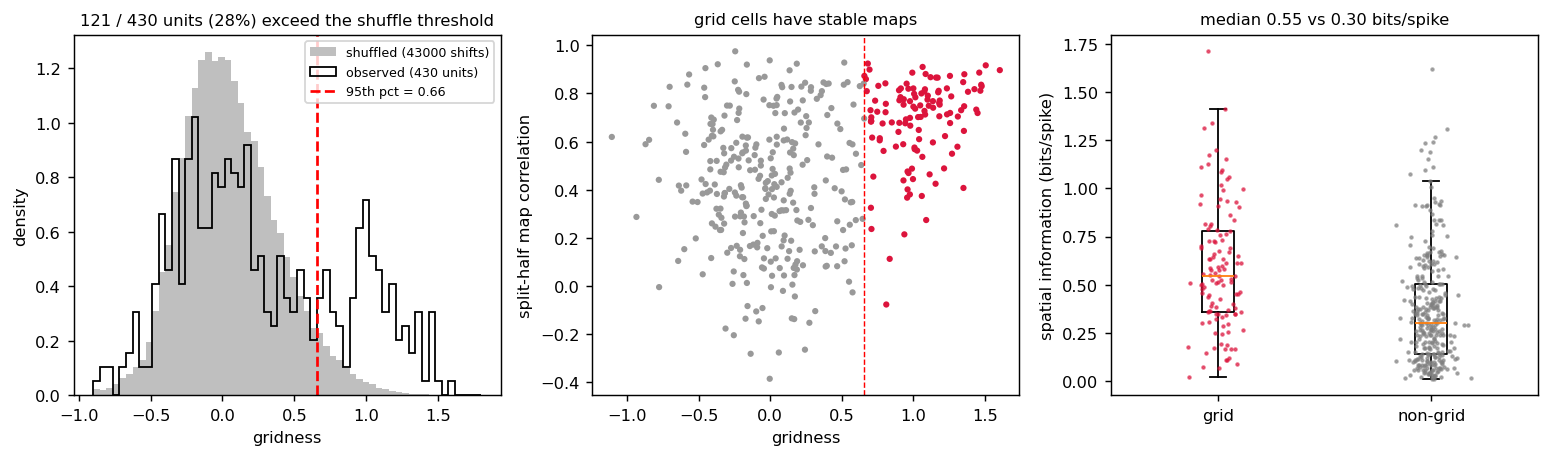

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
bins = np.linspace(-0.9, 1.8, 60)
axes[0].hist(shuf_g.gridness.dropna(), bins=bins, density=True, color="0.75",
             label="shuffled (%d shifts)" % len(shuf_g))
axes[0].hist(units_df.gridness.dropna(), bins=bins, density=True, histtype="step",
             color="k", lw=1.5, label="observed (%d units)" % len(units_df))
axes[0].axvline(G_THR, color="r", ls="--", label="95th pct = %.2f" % G_THR)
axes[0].set_xlabel("gridness"); axes[0].set_ylabel("density"); axes[0].legend(fontsize=7)
axes[0].set_title("%d / %d units (%.0f%%) exceed the shuffle threshold"
                  % (units_df.is_grid.sum(), len(units_df), 100 * units_df.is_grid.mean()))
axes[1].scatter(units_df.gridness, units_df.stability, s=12,
                c=np.where(units_df.is_grid, "crimson", "0.6"), lw=0)
axes[1].axvline(G_THR, color="r", ls="--", lw=0.8)
axes[1].set_xlabel("gridness"); axes[1].set_ylabel("split-half map correlation")
axes[1].set_title("grid cells have stable maps")
d = [units_df.loc[units_df.is_grid, "spatial_info"], units_df.loc[~units_df.is_grid, "spatial_info"]]
axes[2].boxplot(d, tick_labels=["grid", "non-grid"], showfliers=False)
for k, arr in enumerate(d):
    axes[2].plot(np.random.default_rng(k).normal(k + 1, 0.06, len(arr)), arr, ".", ms=3,
                 color="crimson" if k == 0 else "0.5", alpha=0.6)
axes[2].set_ylabel("spatial information (bits/spike)")
axes[2].set_title("median %.2f vs %.2f bits/spike" % (d[0].median(), d[1].median()))
fig.tight_layout()
fig.savefig("fig04_shuffle_classification.png", bbox_inches="tight")

## 11. Geometry of the grid

Spacing is the median distance from the centre of the autocorrelogram to its six
closest peaks; orientation is the angle of the nearest peak, modulo 60 degrees.
Grid cells recorded simultaneously share their orientation far more closely than
cells from different sessions, which is the signature of a common grid network.

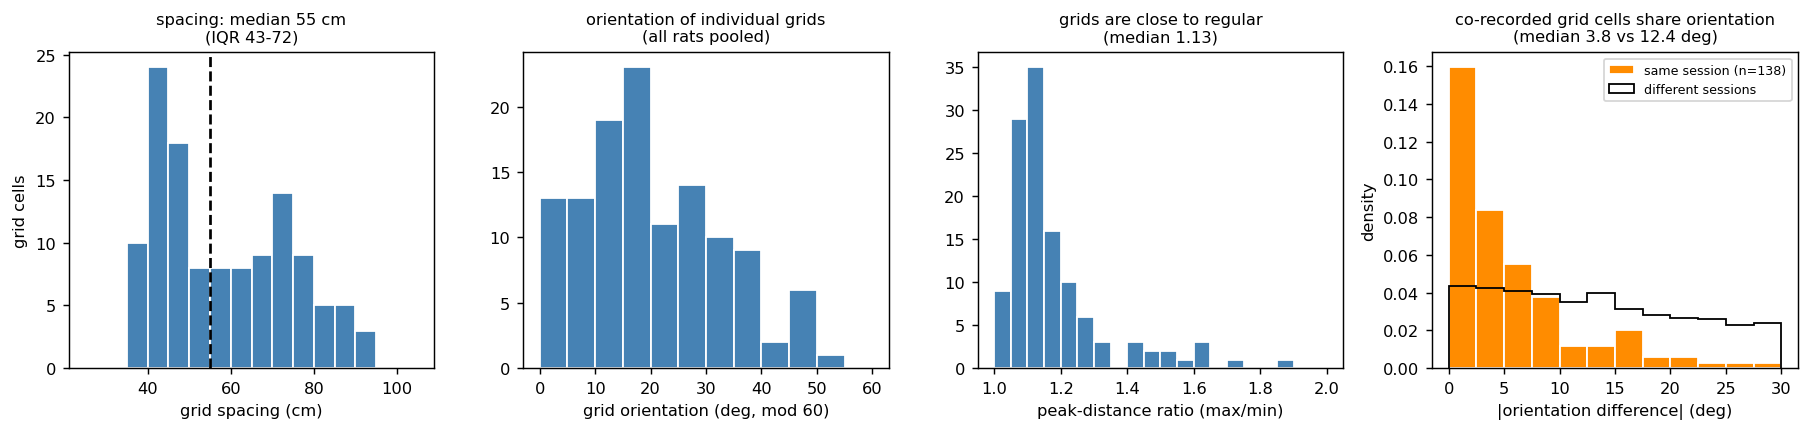

In [11]:
gdf = units_df[units_df.is_grid]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
axes[0].hist(gdf.spacing_cm, bins=np.arange(25, 110, 5), color="steelblue", edgecolor="w")
axes[0].axvline(gdf.spacing_cm.median(), color="k", ls="--")
axes[0].set_xlabel("grid spacing (cm)"); axes[0].set_ylabel("grid cells")
axes[0].set_title("spacing: median %.0f cm\n(IQR %.0f-%.0f)"
                  % (gdf.spacing_cm.median(), gdf.spacing_cm.quantile(0.25),
                     gdf.spacing_cm.quantile(0.75)))
axes[1].hist(gdf.orientation_deg, bins=np.arange(0, 61, 5), color="steelblue", edgecolor="w")
axes[1].set_xlabel("grid orientation (deg, mod 60)")
axes[1].set_title("orientation of individual grids\n(all rats pooled)")
axes[2].hist(gdf.ellipticity, bins=np.arange(1, 2.05, 0.05), color="steelblue", edgecolor="w")
axes[2].set_xlabel("peak-distance ratio (max/min)")
axes[2].set_title("grids are close to regular\n(median %.2f)" % gdf.ellipticity.median())
pairs = []
for path, d_ in gdf.groupby("path"):
    for a in range(len(d_)):
        for b in range(a + 1, len(d_)):
            pairs.append(abs(d_.iloc[a].orientation_deg - d_.iloc[b].orientation_deg))
within = np.minimum(np.array(pairs), 60 - np.array(pairs))
rng = np.random.default_rng(0)
o, sess = gdf.orientation_deg.values, gdf.path.values
a, b = rng.integers(0, len(o), 20000), rng.integers(0, len(o), 20000)
keep = sess[a] != sess[b]
across = np.abs(o[a][keep] - o[b][keep])
across = np.minimum(across, 60 - across)
axes[3].hist(within, bins=np.arange(0, 31, 2.5), density=True, color="darkorange",
             edgecolor="w", label="same session (n=%d)" % len(within))
axes[3].hist(across, bins=np.arange(0, 31, 2.5), density=True, histtype="step", color="k",
             lw=1.4, label="different sessions")
axes[3].set_xlabel("|orientation difference| (deg)"); axes[3].set_ylabel("density")
axes[3].legend(fontsize=7)
axes[3].set_title("co-recorded grid cells share orientation\n(median %.1f vs %.1f deg)"
                  % (np.median(within), np.median(across)))
fig.tight_layout()
fig.savefig("fig05_grid_geometry.png", bbox_inches="tight")

## 12. Layers: grid, head-direction and conjunctive cells

This is the result the dataset was collected for. Grid cells are found in every
principal layer of MEC, but directional tuning is almost absent in layer II and
common in layers III, V and VI, where many cells are conjunctive: they have both a
hexagonal spatial map and a sharp head-direction preference.

/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/time_series.py:3052: UserWarning: Some epochs have no duration
  time_support = IntervalSet(start=ns, end=ne)
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


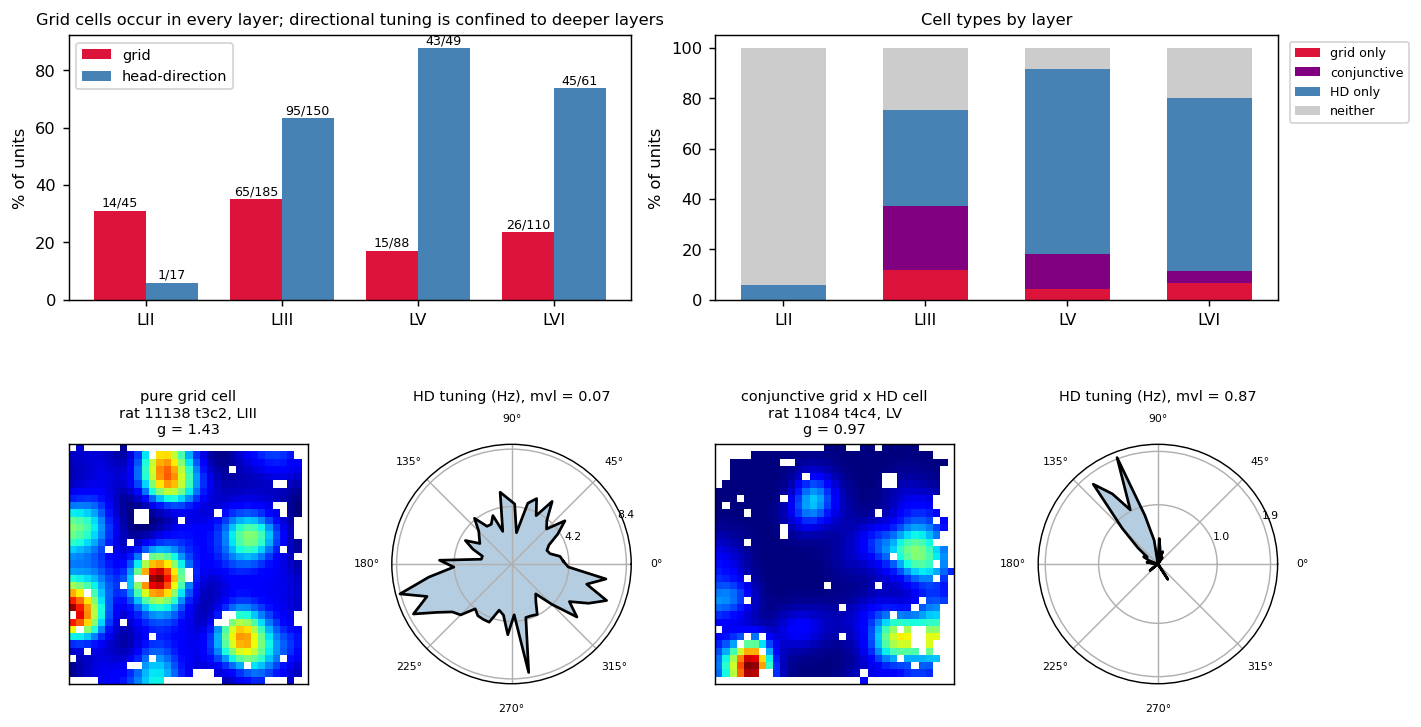

In [12]:
hd_df = units_df[units_df.hd_mvl.notna()]
order = ["MEC LII", "MEC LIII", "MEC LV", "MEC LVI"]
fig = plt.figure(figsize=(12, 6.6))
gsp = fig.add_gridspec(2, 4, hspace=0.5, wspace=0.35)
ax = fig.add_subplot(gsp[0, :2])
w, xs = 0.38, np.arange(len(order))
gr = [units_df[units_df.layer == L].is_grid.mean() * 100 for L in order]
hh = [hd_df[hd_df.layer == L].is_hd.mean() * 100 for L in order]
ax.bar(xs - w / 2, gr, w, label="grid", color="crimson")
ax.bar(xs + w / 2, hh, w, label="head-direction", color="steelblue")
for k, L in enumerate(order):
    ax.text(k - w / 2, gr[k] + 1.5, "%d/%d" % (units_df[units_df.layer == L].is_grid.sum(),
                                               (units_df.layer == L).sum()), ha="center", fontsize=7)
    ax.text(k + w / 2, hh[k] + 1.5, "%d/%d" % (hd_df[hd_df.layer == L].is_hd.sum(),
                                               (hd_df.layer == L).sum()), ha="center", fontsize=7)
ax.set_xticks(xs); ax.set_xticklabels([L.replace("MEC ", "") for L in order])
ax.set_ylabel("% of units"); ax.legend(fontsize=8)
ax.set_title("Grid cells occur in every layer; directional tuning is confined to deeper layers")
ax = fig.add_subplot(gsp[0, 2:])
bottom = np.zeros(len(order))
for c, col in zip(["grid only", "conjunctive", "HD only", "neither"],
                  ["crimson", "purple", "steelblue", "0.8"]):
    vals = []
    for L in order:
        d_ = hd_df[hd_df.layer == L]
        m = {"grid only": d_.is_grid & ~d_.is_hd, "conjunctive": d_.is_grid & d_.is_hd,
             "HD only": ~d_.is_grid & d_.is_hd, "neither": ~d_.is_grid & ~d_.is_hd}[c]
        vals.append(100 * m.mean())
    ax.bar(xs, vals, 0.6, bottom=bottom, label=c, color=col)
    bottom += np.array(vals)
ax.set_xticks(xs); ax.set_xticklabels([L.replace("MEC ", "") for L in order])
ax.set_ylabel("% of units"); ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set_title("Cell types by layer")
conj = units_df[units_df.is_grid & units_df.is_hd].sort_values("hd_mvl", ascending=False).iloc[0]
pure = (units_df[units_df.is_grid & ~units_df.is_hd & units_df.hd_mvl.notna()]
        .sort_values("gridness", ascending=False).iloc[0])
for col, r, lab in [(0, pure, "pure grid cell"), (2, conj, "conjunctive grid x HD cell")]:
    s_ = cached_session(r.path)
    i = unit_index(s_, r.unit)
    e = s_["edges"]
    ax = fig.add_subplot(gsp[1, col])
    ax.imshow(s_["maps"][i], origin="lower", extent=[e[0], e[-1], e[0], e[-1]], cmap="jet")
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("%s\nrat %s %s, %s\ng = %.2f" % (lab, r.subject, r.unit,
                                                  r.layer.replace("MEC ", ""), r.gridness),
                 fontsize=8)
    curves, centers, mvl = hd_tuning(s_["units"], s_["hd"], s_["run_ep"])
    ax = fig.add_subplot(gsp[1, col + 1], projection="polar")
    ax.plot(np.r_[centers, centers[0]], np.r_[curves[:, i], curves[0, i]], color="k")
    ax.fill(np.r_[centers, centers[0]], np.r_[curves[:, i], curves[0, i]],
            color="steelblue", alpha=0.4)
    ax.set_title("HD tuning (Hz), mvl = %.2f" % mvl[i], fontsize=8, pad=24)
    ax.tick_params(labelsize=6)
    rmax = np.nanmax(curves[:, i])
    ax.set_yticks([round(rmax / 2, 1), round(rmax, 1)])
fig.savefig("fig06_layers_and_conjunctive.png", bbox_inches="tight")

## 13. Summary

In [13]:
summary = {
    "sessions": int(units_df.path.nunique()), "rats": int(units_df.subject.nunique()),
    "units": int(len(units_df)), "gridness_threshold": round(G_THR, 3),
    "hd_threshold": round(M_THR, 3), "grid_cells": int(units_df.is_grid.sum()),
    "grid_pct": round(100 * units_df.is_grid.mean(), 1),
    "spacing_median": round(float(gdf.spacing_cm.median()), 1),
    "spacing_iqr": [round(float(gdf.spacing_cm.quantile(0.25)), 1),
                    round(float(gdf.spacing_cm.quantile(0.75)), 1)],
    "stability_grid": round(float(gdf.stability.median()), 2),
    "stability_nongrid": round(float(units_df.loc[~units_df.is_grid, "stability"].median()), 2),
    "grid_pct_by_layer": {L: round(100 * units_df[units_df.layer == L].is_grid.mean(), 1)
                          for L in order},
    "hd_pct_by_layer": {L: round(100 * hd_df[hd_df.layer == L].is_hd.mean(), 1) for L in order},
    "conjunctive_by_layer": {L: int((hd_df[hd_df.layer == L].is_grid
                                     & hd_df[hd_df.layer == L].is_hd).sum()) for L in order},
}
pd.Series(summary).to_json("summary.json", indent=2)
print(json.dumps(summary, indent=2))

{
  "sessions": 84,
  "rats": 15,
  "units": 430,
  "gridness_threshold": 0.658,
  "hd_threshold": 0.203,
  "grid_cells": 121,
  "grid_pct": 28.1,
  "spacing_median": 55.1,
  "spacing_iqr": [
    43.3,
    72.2
  ],
  "stability_grid": 0.73,
  "stability_nongrid": 0.42,
  "grid_pct_by_layer": {
    "MEC LII": 31.1,
    "MEC LIII": 35.1,
    "MEC LV": 17.0,
    "MEC LVI": 23.6
  },
  "hd_pct_by_layer": {
    "MEC LII": 5.9,
    "MEC LIII": 63.3,
    "MEC LV": 87.8,
    "MEC LVI": 73.8
  },
  "conjunctive_by_layer": {
    "MEC LII": 0,
    "MEC LIII": 38,
    "MEC LV": 7,
    "MEC LVI": 3
  }
}


**Result.** Of the 430 MEC units recorded in 1 x 1 m open fields across 84 sessions
and 15 rats, 121 (28%) have a gridness score above the 95th percentile of the
circular-shift shuffle. Their rate maps are hexagonally periodic with a median
spacing of 55 cm (IQR 43-72 cm), their maps are stable within a session (median
split-half correlation 0.73 against 0.42 for the rest of the population) and they
carry more spatial information (0.55 against 0.30 bits/spike). Grid cells recorded
simultaneously have nearly the same grid orientation (median difference 3.8 degrees
against 12.4 degrees for cells from different sessions), as expected if they belong
to a shared network.

Grid cells appear in every layer sampled here (31% in layer II, 35% in layer III,
17% in layer V, 24% in layer VI), while sharp head-direction tuning is essentially
absent in layer II (1 of 17 units with head-direction data) and common below it
(63% in layer III, 88% in layer V, 74% in layer VI). Conjunctive grid x
head-direction cells occur only in the deeper layers (38 in layer III, 7 in layer V,
3 in layer VI, none in layer II). This reproduces the main finding of Sargolini et
al. (2006): position, direction and their conjunction are represented in
systematically different layers of the medial entorhinal cortex.

**Caveats.** The layer II sample is small (45 units, of which only 17 sessions
carried the second tracking LED needed for head direction), so the layer II numbers
are the least well constrained. Cells were assigned to layers from the histology
annotation of the whole recording file rather than per tetrode. Sessions were
deduplicated to one per rat per day, but a cell recorded on consecutive days could
still enter the sample twice.